# Implementing `Scaling Laws for Neural Language Models` By `(Kaplan et al., 2020)`

### 1. Setup and Imports

In [1]:
import os
import math
import time

In [2]:
import warnings
import matplotlib
import numpy as np
import torch.nn as nn
import urllib.request
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from torch.utils.data import Dataset, DataLoader

matplotlib.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.dpi': 100,
})

warnings.filterwarnings('ignore')

/Users/adityamishra/pytorch-test/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
import torch

In [4]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.8.0


In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

### 2. Dataset Preparation

We use **Tiny Shakespeare** — a small (~1MB) text corpus of all Shakespeare works. Since our goal is to show scaling paper we use **character-level tokenization** for simplicity (each character = one token).

In [6]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__))
                         if '__file__' in dir() else '.', 'shakespeare.txt')# 

In [7]:
if not os.path.exists(DATA_PATH):
    print("Downloading Tiny Shakespeare dataset...")
    try:
        urllib.request.urlretrieve(DATA_URL, DATA_PATH)
        print(f"Downloaded to {DATA_PATH}")
    except Exception:
        # Fallback generating synthetic text if download fails
        print("Download failed. Generating synthetic text corpus...")
        np.random.seed(SEED)
        chars = list("abcdefghijklmnopqrstuvwxyz .,:;!?\n'")
        # Create text with some structure (repeated patterns help scaling laws show)
        phrases = [
            "to be or not to be that is the question ",
            "all the world is a stage and all the men and women merely players ",
            "the lady doth protest too much methinks ",
            "brevity is the soul of wit ",
            "though this be madness yet there is method in it ",
            "something is rotten in the state of denmark ",
            "we know what we are but know not what we may be ",
            "love all trust a few do wrong to none ",
            "the course of true love never did run smooth ",
            "all that glitters is not gold ",
        ]
        text_chunks = []
        for _ in range(5000):
            text_chunks.append(np.random.choice(phrases))
        synthetic_text = "".join(text_chunks)
        with open(DATA_PATH, 'w') as f:
            f.write(synthetic_text)
        print(f"Generated {len(synthetic_text)} characters of synthetic text.")

In [8]:
with open(DATA_PATH, 'r') as f:
    raw_text = f.read()

In [9]:
print(f"Dataset size: {len(raw_text):,} characters")
print(f"Sample: {raw_text[:200]}")

Dataset size: 1,115,394 characters
Sample: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


#### Writing Character Level Tokenisation

In [10]:
chars = sorted(list(set(raw_text)))# we get the unique characters in the text and sort them
VOCAB_SIZE = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}# we create a mapping from each character to a unique index
idx_to_char = {i:ch for ch, i in char_to_idx.items()}# we create a reverse mapping from index to character
print(f"Unique characters: {VOCAB_SIZE}")

Unique characters: 65


In [11]:
def encode(text):
    return [char_to_idx[ch] for ch in text]

In [12]:
def decode(indices):
    return "".join([idx_to_char[i] for i in indices])# we convert a list of indices back to text using the reverse mapping

In [13]:
#encoding entire dataset to integers
data = torch.tensor(encode(raw_text), dtype=torch.long)
print(f"Encoded dataset shape: {data.shape}")
print(f"Total tokens: {len(data):,}")
print(f"Vocabulary: {''.join(chars[:50])}...")

Encoded dataset shape: torch.Size([1115394])
Total tokens: 1,115,394
Vocabulary: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijk...


In [14]:
# Train/test split (90/10)
split_idx = int(0.9 * len(data))# we calculate the index for a 90/10 split of the data
train_data = data[:split_idx]# we take the first 90% of the data for training
test_data = data[split_idx:]# we take the remaining 10% of the data for testing
print(f"Train tokens: {len(train_data):,}")
print(f"Test tokens:  {len(test_data):,}")

Train tokens: 1,003,854
Test tokens:  111,540


#### Writing Dataset and Dataloader

In [15]:
class TextDataset(Dataset):
    
    def __init__(self, data, context_length):
        self.data = data
        self.context_length = context_length# we store the data and the context length for later use
        
    def __len__(self):
        return max(1, len(self.data) - self.context_length)# the length of the dataset is the total number of tokens minus the context length since we need at least context_length tokens to create one training example
    
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.context_length]# we take a slice of the data from the current index to the index plus the context length to create the input sequence
        y = self.data[idx + 1 : idx + self.context_length + 1]# we take a slice of the data from the current index plus one to the index plus the context length plus one to create the target sequence (the next character for each input character)
        return x, y

In [16]:
def create_dataloader(data, context_length, batch_size, shuffle=True):
    dataset = TextDataset(data, context_length)# we create an instance of the TextDataset with the given data and context length
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=True)# we create a DataLoader from the dataset with the specified batch size and shuffle option and we drop the last batch if it's smaller than the batch size

### 3. Implementing Mini Transformer from Scratch

In [17]:
class MultiHeadAttention(nn.Module):
    
    def __init__(self, d_model, n_heads, context_length, dropout = 0.0):
        super().__init__()# we initialize the MultiHeadAttention class which inherits from nn.Module and takes in the model dimension, number of heads, context length, and dropout rate as parameters
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"# we assert that the model dimension must be divisible by the number of heads to ensure that we can split the model dimension evenly across the heads
        self.n_heads = n_heads# we store the number of heads for later use
        self.head_dim = d_model // n_heads# we calculate the dimension of each head by dividing the model dimension by the number of heads
        
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

        # mask to prevent attending to future tokens
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(context_length, context_length))
                 .view(1, 1, context_length, context_length)
        )

    def forward(self, x):
        B, T, C = x.shape

        # Project to Q, K, V
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        # Reshape for multi-head: (B, T, C) -> (B, n_heads, T, head_dim)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Scaled dotproduct attention with causal mask
        scale = math.sqrt(self.head_dim)
        attn = (q @ k.transpose(-2, -1)) / scale# we compute the attention scores by performing a matrix multiplication between the query and the transpose of the key and then scaling by the square root of the head dimension
        attn = attn.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))# we apply a causal mask to the attention scores to prevent attending to future tokens by setting the scores for those positions to negative infinity
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        # Apply attention to values
        out = attn @ v  # (B, n_heads, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

In [18]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.0):
        super().__init__()
        d_ff = d_ff or 4 * d_model  # Standard ratio from the paper
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )# we initialize the FeedForward class which inherits from nn.Module and takes in the model dimension, feedforward dimension (defaulting to 4 times the model dimension), and dropout rate as parameters and we create a sequential feedforward network with a linear layer, GELU activation, another linear layer, and dropout

    def forward(self, x):
        return self.net(x)

In [19]:
class TransformerBlock(nn.Module):
    # we initialize the TransformerBlock class which inherits from nn.Module and takes in the model dimension, number of heads, context length, and dropout rate as parameters and we create the components of a single transformer block including layer normalization, multi-head attention, another layer normalization, and a feedforward network with residual connections around the attention and feedforward layers
    def __init__(self, d_model, n_heads, context_length, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(
            d_model, n_heads, context_length, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # Residual around attention
        x = x + self.ffn(self.ln2(x))    # Residual around FFN
        return x

In [20]:
# charcter level language model with a small transformer architecture
class MiniTransformer(nn.Module):
    
    def __init__(self, vocab_size, d_model, n_heads, n_layers, context_length, dropout = 0.0):
        super().__init__()
        self.context_length = context_length

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_length, d_model)
        self.drop = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, context_length, dropout)
            for _ in range(n_layers)
        ])

        # Output head
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # (B, T, d_model)
        tok_emb = self.token_emb(idx)
        pos_emb = self.pos_emb(torch.arange(
            T, device=idx.device))  # (T, d_model)
        x = self.drop(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

In [21]:
def count_parameters(model, exclude_embeddings=True):
    """
    Count non-embedding parameters as done in the paper
    """
    total = sum(p.numel() for p in model.parameters())
    if exclude_embeddings:
        emb_params = sum(p.numel() for name, p in model.named_parameters()
                         if 'emb' in name)
        return total - emb_params
    return total

In [22]:
def create_model(n_layers, d_model, n_heads, context_length=64, vocab_size=VOCAB_SIZE):
    """Factory function to create a MiniTransformer with given hyperparameters."""
    model = MiniTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        context_length=context_length,
        dropout=0.0,  # No dropout for cleaner scaling experiments
    )
    return model.to(DEVICE)

In [23]:
test_model = create_model(n_layers=2, d_model=64, n_heads=2)
n_params = count_parameters(test_model)
print(f"Test model: {n_params:,} non-embedding parameters")
dummy_input = torch.randint(0, VOCAB_SIZE, (2, 64)).to(DEVICE)
logits, _ = test_model(dummy_input)
print(f"Output shape: {logits.shape}")
del test_model

Test model: 103,744 non-embedding parameters
Output shape: torch.Size([2, 64, 65])


### 4. Training Infrastructure

In [24]:
@torch.no_grad()
def evaluate_model(model, test_data, context_length=64, batch_size=64, max_batches=50):
    """Evaluate model on test data and return average loss."""
    model.eval()
    test_loader = create_dataloader(
        test_data, context_length, batch_size, shuffle=False)

    total_loss = 0.0
    count = 0
    for i, (xb, yb) in enumerate(test_loader):
        if i >= max_batches:
            break
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        _, loss = model(xb, yb)
        total_loss += loss.item()
        count += 1

    model.train()
    return total_loss / max(count, 1)

In [25]:
def train_model(model, train_data, test_data, context_length=64, batch_size=64,
                learning_rate=3e-4, num_steps=1000, eval_every=200, verbose=True):
    """
    Train a model and return training history.
    
    Returns:
        dict with keys: 'train_losses', 'test_losses', 'steps', 'final_test_loss',
                        'total_tokens_seen', 'total_flops'
    """
    train_loader = create_dataloader(train_data, context_length, batch_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Cosine learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_steps)

    n_params = count_parameters(model)
    train_losses = []
    test_losses = []
    steps_record = []
    tokens_seen = 0

    model.train()
    step = 0
    train_iter = iter(train_loader)

    start_time = time.time()

    while step < num_steps:
        # Get next batch (cycle through data)
        try:
            xb, yb = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)

        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        # Forward pass
        _, loss = model(xb, yb)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        tokens_seen += xb.numel()
        step += 1

        # Evaluate periodically
        if step % eval_every == 0 or step == num_steps:
            test_loss = evaluate_model(
                model, test_data, context_length, batch_size)
            train_losses.append(loss.item())
            test_losses.append(test_loss)
            steps_record.append(step)

            if verbose:
                elapsed = time.time() - start_time
                print(f"  Step {step:5d}/{num_steps} | "
                      f"Train Loss: {loss.item():.4f} | "
                      f"Test Loss: {test_loss:.4f} | "
                      f"Time: {elapsed:.1f}s")

    # Compute total FLOPs: C ≈ 6 * N * D (approximate)
    total_flops = 6 * n_params * tokens_seen

    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'steps': steps_record,
        'final_test_loss': test_losses[-1],
        'total_tokens_seen': tokens_seen,
        'total_flops': total_flops,
        'n_params': n_params,
    }

#### Power Law:

In [26]:
def power_law(x, a, alpha):
    """Power law function: L = a * x^(-alpha)"""
    return a * np.power(x, -alpha)

In [27]:
def fit_power_law(x_data, y_data):
    """
    Fit a power law L = a * x^(-alpha) to data.
    Returns (a, alpha, r_squared).
    """
    try:
        # Fit in log-log space for better numerical stability
        log_x = np.log(x_data)
        log_y = np.log(y_data)

        # Linear fit in log space: log(y) = log(a) - alpha * log(x)
        coeffs = np.polyfit(log_x, log_y, 1)
        alpha = -coeffs[0]
        a = np.exp(coeffs[1])

        # R-squared
        y_pred = power_law(x_data, a, alpha)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - ss_res / ss_tot

        return a, alpha, r_squared
    except Exception as e:
        print(f"Warning: Power law fit failed: {e}")
        return 1.0, 0.1, 0.0

In [29]:
def plot_scaling_law(x_data, y_data, x_label, title, a, alpha, r_sq,
                     color='#2196F3', save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Data points
    ax.scatter(x_data, y_data, color=color, s=80, zorder=5,
               edgecolors='white', linewidth=1.5, label='Measured')

    # Fitted curve
    x_fit = np.logspace(np.log10(min(x_data) * 0.5),
                        np.log10(max(x_data) * 2), 100)
    y_fit = power_law(x_fit, a, alpha)
    ax.plot(x_fit, y_fit, '--', color='#FF5722', linewidth=2, alpha=0.8,
            label=f'Fit: L = {a:.2f} × {x_label[0]}^(-{alpha:.4f})\nR² = {r_sq:.4f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(x_label, fontsize=13)
    ax.set_ylabel('Test Loss (Cross-Entropy)', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

### 5. Implementing Experiments

#### Experiment 1: Scaling with Model Size (N)

EXPERIMENT 1: Scaling with Model Size (N)

Config 1/12: layers=1, d_model=16, heads=1:
  Non-embedding params: 4,288
  Step  2000/2000 | Train Loss: 2.5511 | Test Loss: 2.6021 | Time: 11.6s

Config 2/12: layers=1, d_model=32, heads=1:
  Non-embedding params: 14,720
  Step  2000/2000 | Train Loss: 2.3199 | Test Loss: 2.3778 | Time: 11.1s

Config 3/12: layers=2, d_model=32, heads=2:
  Non-embedding params: 27,296
  Step  2000/2000 | Train Loss: 2.3323 | Test Loss: 2.3866 | Time: 21.0s

Config 4/12: layers=2, d_model=48, heads=2:
  Non-embedding params: 59,376
  Step  2000/2000 | Train Loss: 2.2030 | Test Loss: 2.2565 | Time: 24.7s

Config 5/12: layers=2, d_model=64, heads=2:
  Non-embedding params: 103,744
  Step  2000/2000 | Train Loss: 2.0443 | Test Loss: 2.0933 | Time: 26.5s

Config 6/12: layers=3, d_model=64, heads=2:
  Non-embedding params: 153,472
  Step  2000/2000 | Train Loss: 1.9818 | Test Loss: 2.0967 | Time: 37.0s

Config 7/12: layers=4, d_model=64, heads=4:
  Non-embedding pa

FileNotFoundError: [Errno 2] No such file or directory: 'plots/exp1_model_size_scaling.png'

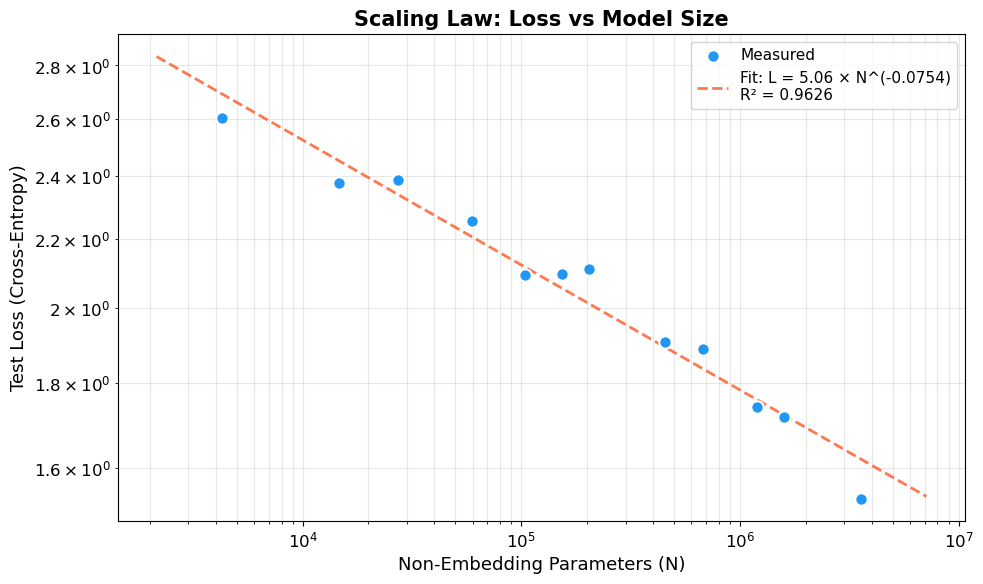

In [ ]:
print("EXPERIMENT 1: Scaling with Model Size (N)")

# Define model configurations: (n_layers, d_model, n_heads) and vary these to get a range of parameter counts
MODEL_CONFIGS = [
    (1, 16, 1),     # Tiny
    (1, 32, 1),     # Very small
    (2, 32, 2),     # Small
    (2, 48, 2),     # Small-medium
    (2, 64, 2),     # Medium-small
    (3, 64, 2),     # Medium
    (4, 64, 4),     # Medium-large
    (4, 96, 4),     # Large
    (6, 96, 4),     # Larger
    (6, 128, 4),    # Even larger
    (8, 128, 8),    # XL
    (8, 192, 8),    # XXL
]

CONTEXT_LENGTH = 64
NUM_STEPS_EXP1 = 2000   # Enough steps for smaller models to converge
BATCH_SIZE = 64
LR = 3e-4

exp1_results = []

for i, (n_layers, d_model, n_heads) in enumerate(MODEL_CONFIGS):
    print(f"\nConfig {i+1}/{len(MODEL_CONFIGS)}: "
          f"layers={n_layers}, d_model={d_model}, heads={n_heads}:")

    torch.manual_seed(SEED)
    model = create_model(n_layers, d_model, n_heads, CONTEXT_LENGTH)
    n_params = count_parameters(model)
    print(f"  Non-embedding params: {n_params:,}")

    history = train_model(
        model, train_data, test_data,
        context_length=CONTEXT_LENGTH, batch_size=BATCH_SIZE,
        learning_rate=LR, num_steps=NUM_STEPS_EXP1,
        eval_every=NUM_STEPS_EXP1,  # Only evaluate at end for speed
        verbose=True,
    )

    exp1_results.append({
        'n_params': n_params,
        'test_loss': history['final_test_loss'],
        'config': (n_layers, d_model, n_heads),
    })

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\n\nExperiment 1 Results:")
print(f"{'Config':<20} {'Params':>10} {'Test Loss':>12}")
for r in exp1_results:
    print(f"{str(r['config']):<20} {r['n_params']:>10,} {r['test_loss']:>12.4f}")

#Scaling Law for Model Size 
N_values = np.array([r['n_params'] for r in exp1_results])
L_values = np.array([r['test_loss'] for r in exp1_results])

a_N, alpha_N, r_sq_N = fit_power_law(N_values, L_values)
print(f"\nPower Law Fit: L(N) = {a_N:.2f} × N^(-{alpha_N:.4f})")
print(f"R² = {r_sq_N:.4f}")
print(f"Paper's exponent: α_N ≈ 0.076 | Our exponent: α_N ≈ {alpha_N:.4f}")